# Cost modelling

In [3]:
from datetime import datetime
from io import StringIO
import json
import os
from pathlib import Path

from IPython.display import display, Image, Latex
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pprint import pprint
import scipy
from scipy.optimize import curve_fit
import sklearn
from sklearn.linear_model import LinearRegression

from phdtools import DATA_DIR, RESULTS_DIR
from phdtools.rdm import (
    DataID,
    DataType,
    Chapter,
    request_free_id,
    auto_create_path,
    write_metadata,
)

TODAY = datetime.today().strftime("%y%m%d")
FILE_DATE = os.getenv("FILE_DATE", "260321")

overwrite = False
if overwrite:
    FILE_DATE = TODAY

## Table of contents

1. [Published cost data](#Published-cost-data)
    1. [Heat exchangers](#Heat-exchangers)
    2. [Direct-fired heaters](#Direct-fired-heaters)
2. [Cost models](#Cost-models)
    1. [Single term scaling-law](#Single-term-scaling-law)
    2. [Single variable scaling-law with constant](#Single-variable-scaling-law-with-constant)
    3. [Model comparison](#Model-comparison)
3. [Reactor costs](#Reactor-costs)
    1. [Reformer](#Reformer)
    2. [Shift reactor](#Shift-reactor)
    3. [Reactor cost comparison](#Reactor-cost-comparison)

## Published cost data
[back](#Table-of-contents)

In [4]:
!ls {DATA_DIR / "peters-2004"}

260210_fig_14_17_u_tube_hex.csv
260210_fig_14_18_fixed_tube_sheet_hex.csv
260210_fig_14_38_direct_fired_heaters.csv


### Heat-exchangers
[back](#Table-of-contents)

In [5]:
df = pd.read_csv(DATA_DIR / "peters-2004" / "260210_fig_14_17_u_tube_hex.csv")
df.head()

,Surface area (m2),Carbon steel,Stainless steel
0,3,2410.6229,3218.1373
1,4,2574.2243,3527.9995
2,5,2730.9377,3842.3840
3,6,2859.3924,4157.3950
4,7,2974.2949,4439.5444


In [6]:
df = pd.read_csv(DATA_DIR / "peters-2004" / "260210_fig_14_18_fixed_tube_sheet_hex.csv")
df.head()

,Surface area (m2),Carbon-steel tubes,304 Stainless-steel tubes,316 Stainless-steel tubes
0,4,2866.5273,3085.5957,3370.6880
1,5,2996.0278,3297.0358,3601.6640
2,6,3131.3788,3497.1159,3792.2002
3,7,3272.8445,3682.1212,3992.8162
4,8,3395.6025,3876.9138,4204.0452


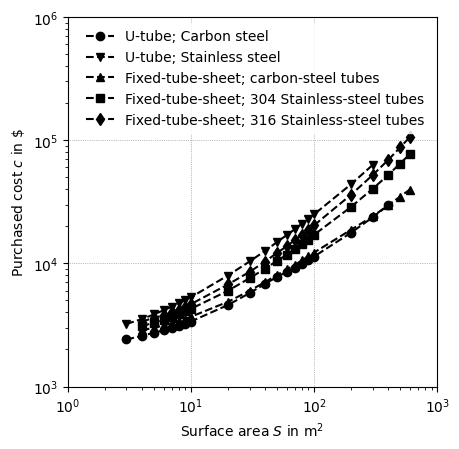

In [7]:
from phdtools.plots.cost_modelling import plot_heat_exchanger_cost

fig = plot_heat_exchanger_cost()

### Direct-fired heaters
[back](#Table-of-contents)

In [8]:
fname = DATA_DIR / "peters-2004" / "260210_fig_14_38_direct_fired_heaters.csv"

df = pd.read_csv(fname)
df.head()

,Heat duty (kW),Carbon-steel tubes (690 kPa),Carbon-steel tubes (3450 kPa),Stainless-steel tubes (10340 kPA),Chrome/moly tubes (6895 kPa)
0,100,NaN,21067.47163,30978.68860,33929.21780
1,200,10124.22002,33324.70046,49002.34526,53902.39312
2,300,13705.72135,43955.73665,64077.15767,70790.82809
3,400,17015.98375,53172.00370,77848.64636,86378.62499
4,500,20231.31284,61864.66881,90184.18164,100499.97470


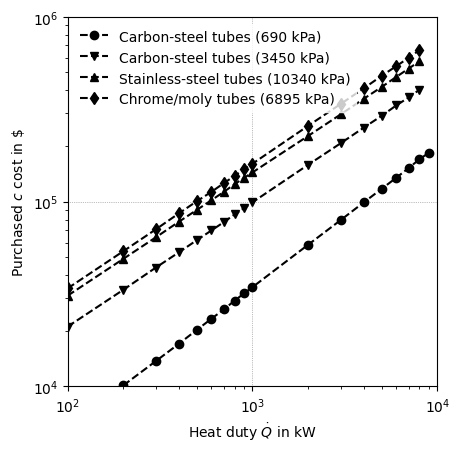

In [9]:
from phdtools.plots.cost_modelling import plot_direct_fired_heater_costs

_ = plot_direct_fired_heater_costs()

## Cost models
[back](#Table-of-contents)

### Single term scaling-law
[back](#Table-of-contents)

$$
\frac{C}{C_0} = \left(\frac{x}{x_0}\right)^{\kappa} \implies \log{C} = \kappa \log{x} + \underbrace{\log{C_0} - \kappa \log{x_0}}_{\log b}
$$

In [10]:
def singleTermCostModel(x, b, k):
    return b * (x) ** k


def fit_single_term_cost_model(x, y):

    X_train = np.log(x).reshape(-1, 1)
    Y_train = np.log(y)

    reg = LinearRegression(fit_intercept=True).fit(X_train, Y_train)

    return reg.coef_[0], reg.intercept_

In [11]:
df = pd.read_csv(DATA_DIR / "peters-2004" / "260210_fig_14_18_fixed_tube_sheet_hex.csv")
df.head()

,Surface area (m2),Carbon-steel tubes,304 Stainless-steel tubes,316 Stainless-steel tubes
0,4,2866.5273,3085.5957,3370.6880
1,5,2996.0278,3297.0358,3601.6640
2,6,3131.3788,3497.1159,3792.2002
3,7,3272.8445,3682.1212,3992.8162
4,8,3395.6025,3876.9138,4204.0452


In [12]:
mask = df["Surface area (m2)"] > 10

k, log_b = fit_single_term_cost_model(
    x=df[mask]["Surface area (m2)"].to_numpy(),
    y=df[mask]["Carbon-steel tubes"].to_numpy(),
)

x0 = 1
c0 = np.exp(log_b) * x0**k

Latex(rf"$S_0 = {x0} \, \mathrm{{m}}^2$, $c_0 = {c0:.4f}$, $k = {k:.4f}$")

<IPython.core.display.Latex object>

> Note: For large surface area the cost estimate agrees well with the six-tenth rule!

### Single variable scaling-law with constant
[back](#Table-of-contents)

$$
\frac{C}{C_0} = a_1 + a_2 \, \left(\frac{x}{x_0}\right)^{\kappa}
$$

In [13]:
def singleVariableCostModel(x, a, b, c):
    return a + b * x**c

In [14]:
df = pd.read_csv(DATA_DIR / "peters-2004" / "260210_fig_14_18_fixed_tube_sheet_hex.csv")
df.head()

,Surface area (m2),Carbon-steel tubes,304 Stainless-steel tubes,316 Stainless-steel tubes
0,4,2866.5273,3085.5957,3370.6880
1,5,2996.0278,3297.0358,3601.6640
2,6,3131.3788,3497.1159,3792.2002
3,7,3272.8445,3682.1212,3992.8162
4,8,3395.6025,3876.9138,4204.0452


In [15]:
mask = df["Surface area (m2)"] >= 0

S0 = 1
c0 = 1

x_data = df["Surface area (m2)"].to_numpy() / c0
y_data = df["Carbon-steel tubes"].to_numpy() / S0

popt, _ = curve_fit(
    singleVariableCostModel, x_data, y_data, bounds=(0, [np.inf, np.inf, np.inf])
)

Latex(
    rf"$a_1 = {popt[0]:.2f} \, \mathrm{{m}}^2$, $a_2 = {popt[1]:.2f}$, $k = {popt[2]:.4f}$"
)

<IPython.core.display.Latex object>

### Model comparison
[back](#Table-of-contents)

In [16]:
# request_free_id(DataType.SUPPORT, Chapter.METHODS)

In [17]:
data_id = DataID(DataType.SUPPORT, Chapter.METHODS, 6)


@auto_create_path
def save_regression_coefficients(path):

    coefs = dict()

    description = (
        "Cost correlations fitted with data taken from Peters (2004, figs. 14-17, 14-18, and 14-38).\n"
        "Two scaling models were fitted. The first (single variable model without constant) is a scaling\n"
        "model of the form \n\n"
        "    c/c0 = (x/x0)^k \n\n"
        "This model fitted with a linear regression model in log space using sklearl.linear_model.LinearRegression\n"
        f"(scikit-learn {sklearn.__version__}).\n"
        "The second model adds a constant term: \n\n"
        "    c/c0 = a1 + a2 (x/x0)^k \n\n"
        "It was estimated via a non-linear least squares regression using the Scipy implementation \n"
        f"scipy.optimize.curve_fit (scipy {scipy.__version__}).\n"
        "NOTE: c0 is taken here as 1 $ and x0 as 1 unit of x for ease of use.\n"
        "The training data were extracted at each major logarithmic tick mark including decadal subdivisions.\n"
        "In the case of figs. 14-17 and 14-18, only values greater 10m2 were considered in the scaling model without constant.\n"
        "\n"
        "References\n"
        "-----------\n"
        "Peters (2004): Plant design and economics for chemical engineers.\n"
        "    5. ed, international ed. 2004. Boston: McGraw-Hill (McGraw-Hill\n"
        "    chemical engineering series).\n\n"
        "Virtanen, P. et al. (2020) “SciPy 1.0: fundamental algorithms for scientific\n"
        "    computing in Python,” Nature Methods, 17(3), pp. 261–272. Available at:\n"
        "    https://doi.org/10.1038/s41592-019-0686-2.\n\n"
        "Pedregosa, F. et al. (2011) “Scikit-learn: Machine learning in Python,” Journal\n"
        "    of Machine Learning Research, 12, pp. 2825–2830.\n"
    )
    with StringIO() as f:
        write_metadata(f, description)
        coefs["_metadata"] = f.getvalue()

    _data = [
        (
            "Fixed-tube-sheet heat exchanger",
            DATA_DIR / "peters-2004" / "260210_fig_14_18_fixed_tube_sheet_hex.csv",
        ),
        (
            "U-tube heat exchanger",
            DATA_DIR / "peters-2004" / "260210_fig_14_17_u_tube_hex.csv",
        ),
        (
            "Direct-fired heaters",
            DATA_DIR / "peters-2004" / "260210_fig_14_38_direct_fired_heaters.csv",
        ),
    ]

    x0 = 1
    for _type, _fname in _data:
        _tmp = pd.read_csv(_fname, index_col=0).dropna()

        if _type in ("Fixed-tube-sheet heat exchanger", "U-tube heat exchanger"):
            mask = _tmp.index > 10  # fit only large values for model w/o constant
        else:
            mask = _tmp.index >= 0

        coefs[_type] = dict()
        for _subtype in _tmp.columns:
            coefs[_type][_subtype] = dict()

            # Model A
            k, logb = fit_single_term_cost_model(
                x=_tmp[mask].index.to_numpy(), y=_tmp[mask][_subtype].to_numpy()
            )

            coefs[_type][_subtype]["Single variable model w/o constant"] = {
                "Ansatz": r"$c/c_0 = (x/x_0)^k$",
                "c0": float(np.exp(logb) * x0**k),
                "x0": float(x0),
                "k": float(k),
            }

            # Model B
            popt, _ = curve_fit(
                singleVariableCostModel,
                _tmp.index.to_numpy(),
                _tmp[_subtype].to_numpy(),
                bounds=(0, [np.inf, np.inf, np.inf]),
            )

            coefs[_type][_subtype]["Single variable model with constant"] = {
                "Ansatz": r"$c/c_0 = a_1 + a_2 \, (x/x_0)^k$",
                "a1": float(popt[0]),
                "a2": float(popt[1]),
                "k": float(popt[2]),
                "c0": 1,
                "x0": 1,
            }

    fname = path / f"{TODAY}_cost_coefficients.json"
    with open(fname, "w") as f:
        json.dump(coefs, f, indent=4)


save_regression_coefficients(
    data_id,
    doc=(
        r"Purchased equipment cost correlations for U-tube heat exchangers, fixed-tube-sheet heat exchangers, "
        r"and direct fired heaters based on data taken from \textcite{Peters.2004a}"
    ),
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools-dev/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/lDiIGQ' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [18]:
!ls {DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)}

260407_cost_coefficients.json


In [19]:
fname = (
    DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
    / f"{FILE_DATE}_cost_coefficients.json"
)
with open(fname) as f:
    costCoefficients = json.load(f)

print(costCoefficients["_metadata"])

# METADATA
# Author: Marvin Meck
# ORCiD: https://orcid.org/0000-0003-2930-8220
# Date: 2026-04-07 17:29:19.260940
# Description: Cost correlations fitted with data taken from Peters (2004, figs. 14-17, 14-18, and 14-38).
#   Two scaling models were fitted. The first (single variable model without constant) is a scaling
#   model of the form 
#   
#       c/c0 = (x/x0)^k 
#   
#   This model fitted with a linear regression model in log space using sklearl.linear_model.LinearRegression
#   (scikit-learn 1.8.0).
#   The second model adds a constant term: 
#   
#       c/c0 = a1 + a2 (x/x0)^k 
#   
#   It was estimated via a non-linear least squares regression using the Scipy implementation 
#   scipy.optimize.curve_fit (scipy 1.17.1).
#   NOTE: c0 is taken here as 1 $ and x0 as 1 unit of x for ease of use.
#   The training data were extracted at each major logarithmic tick mark including decadal subdivisions.
#   In the case of figs. 14-17 and 14-18, only values greater 10m2 were conside

In [20]:
costCoefficients["Fixed-tube-sheet heat exchanger"]["Carbon-steel tubes"][
    "Single variable model w/o constant"
]

{'Ansatz': '$c/c_0 = (x/x_0)^k$',
 'c0': 709.5761636782746,
 'x0': 1.0,
 'k': 0.6219671486373989}

In [21]:
costCoefficients["Fixed-tube-sheet heat exchanger"]["Carbon-steel tubes"][
    "Single variable model with constant"
]

{'Ansatz': '$c/c_0 = a_1 + a_2 \\, (x/x_0)^k$',
 'a1': 1857.5751349267703,
 'a2': 348.4397744746754,
 'k': 0.7318913475324915,
 'c0': 1,
 'x0': 1}

In [22]:
# request_free_id(DataType.FIGURE, Chapter.UNUSED)

In [23]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 22)


@auto_create_path
def save_cost_correlation_plot(path, fname_coefs):

    with open(fname_coefs) as f:
        costCoefficients = json.load(f)

    for _type in costCoefficients.keys():
        if _type == "_metadata":
            continue
        elif _type == "Fixed-tube-sheet heat exchanger":
            _var = "Surface area (m2)"
            x = np.geomspace(1, 1000)
        elif _type == "U-tube heat exchanger":
            _var = "Surface area (m2)"
            x = np.geomspace(1, 1000)
        elif _type == "Direct-fired heaters":
            _var = "Heat duty (kW)"
            x = np.geomspace(1e2, 1e4)
        else:
            NotImplementedError(f"Unknown type! {_type}")

        _tmp = pd.DataFrame()
        for _subtype in costCoefficients[_type].keys():
            fname = path / (
                f"{TODAY}_"
                + _type.replace("-", "_").replace(" ", "_").lower()
                + "_"
                + _subtype.replace("-", "_").replace(" ", "_").replace("/", "_").lower()
                + ".csv"
            )

            coefsA = costCoefficients[_type][_subtype][
                "Single variable model w/o constant"
            ]
            coefsB = costCoefficients[_type][_subtype][
                "Single variable model with constant"
            ]

            description = (
                "Purchased cost values determined from differnent variants of scaling model.\n"
                "based on data from Peters (2004).\n\n"
                "  Model A: c/c0 = (x/x0)^k"
                f" with c0 = {coefsA["c0"]:.2f}, x0 = {coefsA["x0"]:.2f}, and k = {coefsA["k"]:.4f}.\n"
                "  Model B: c/c0 = a1 + a2 (x/x0)^k"
                f" with a1 = {coefsB["a1"]:.2f}, a2 = {coefsB["a2"]:.2f}, and k = {coefsB["k"]:.4f}.\n"
                "\n"
                f"The coefficients and metadata are given in\n\n"
                f"   RESULTS_DIR/{os.path.relpath(fname_coefs, RESULTS_DIR)}.\n"
                "\n"
                "References\n"
                "-----------\n"
                "Peters (2004): Plant design and economics for chemical engineers.\n"
                "    5. ed, international ed. 2004. Boston: McGraw-Hill (McGraw-Hill\n"
                "    chemical engineering series).\n\n"
            )

            costValuesA = singleTermCostModel(x, b=coefsA["c0"], k=coefsA["k"])
            costValuesB = singleVariableCostModel(
                x, coefsB["a1"], coefsB["a2"], coefsB["k"]
            )

            with open(fname, "w+") as f:
                write_metadata(f, description=description)
                np.savetxt(
                    f,
                    np.c_[x, costValuesA, costValuesB],
                    header=f"{_var},model A,model B",
                    delimiter=",",
                )


save_cost_correlation_plot(
    data_id,
    fname_coefs=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_coefficients.json"
    ),
    doc=r"Purchased equipment cost estimates determined from different scaling models based on data from \textcite{Peters.2004a}",
    overwrite=overwrite,
)

/Users/marvinmeck/test/phd-tools-dev/phdtools/rdm.py:142: UserWarning: Results path '/Users/marvinmeck/phd-results/6VgZxL' already exists. The data_id has been used before. This may be because the results already exist. Skipping!
  warnings.warn(


In [24]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 22).get_path(fail_exists=False)}

260407_direct_fired_heaters_carbon_steel_tubes_(3450_kpa).csv
260407_direct_fired_heaters_carbon_steel_tubes_(690_kpa).csv
260407_direct_fired_heaters_chrome_moly_tubes_(6895_kpa).csv
260407_direct_fired_heaters_stainless_steel_tubes_(10340_kpa).csv
260407_fixed_tube_sheet_heat_exchanger_304_stainless_steel_tubes.csv
260407_fixed_tube_sheet_heat_exchanger_316_stainless_steel_tubes.csv
260407_fixed_tube_sheet_heat_exchanger_carbon_steel_tubes.csv
260407_u_tube_heat_exchanger_carbon_steel.csv
260407_u_tube_heat_exchanger_stainless_steel.csv


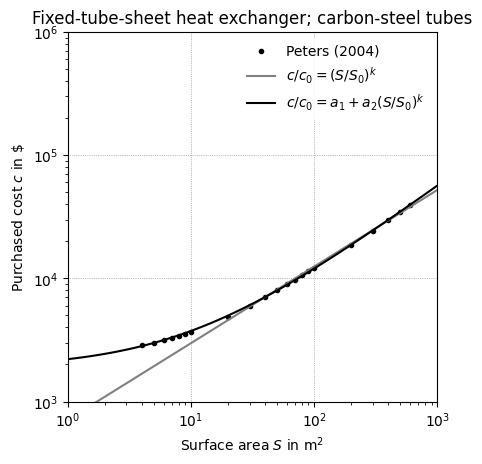

In [25]:
from phdtools.plots.cost_modelling import plot_cost_model

_ = plot_cost_model(
    fname_data=DATA_DIR / "peters-2004" / "260210_fig_14_18_fixed_tube_sheet_hex.csv",
    fname_model=(
        DataID(DataType.FIGURE, Chapter.UNUSED, 22).get_path(fail_exists=False)
        / f"{FILE_DATE}_fixed_tube_sheet_heat_exchanger_carbon_steel_tubes.csv"
    ),
    x_name_data="Surface area (m2)",
    y_name_data="Carbon-steel tubes",
    title="Fixed-tube-sheet heat exchanger; carbon-steel tubes",
    label="Peters (2004)",
)

## Reactor costs
[back](#Table-of-contents)

In [26]:
from phdtools.optimization.preprocessing import get_plugFlowReactorCostCoefficients

$
\newcommand{\CostTerm}[1]{c_{#1}}
\newcommand{\VoidFraction}{\varepsilon}
\newcommand{\Volume}[1]{V_{#1}}
\newcommand{\MassOfSolids}[1]{W_{#1}}
\newcommand{\MassDensity}[1]{\varrho_{#1}}
\newcommand{\Number}[1]{N_{#1}}
\newcommand{\OuterDiameter}[1]{D_{#1}}
\newcommand{\WallThickness}[1]{s_{#1}}
\newcommand{\Length}[1]{L_{#1}}
\newcommand{\SurfaceArea}[1]{S_{#1}}
$With the void fraction of the catalyst bed defined by $\VoidFraction{} \coloneqq \Volume{} / \Volume{r}$, where $\Volume{}$ denotes the gas volume and $\Volume{r}$ denotes the geometric reactor volume [(Levenspiel, 1999, p. 91)](#References), the catalyst mass $\MassOfSolids{}$ is related to the reactor volume $\Volume{r}$ by
$$
\begin{align}
  \MassOfSolids{} = \MassDensity{s} \left(1 - \VoidFraction{}\right) \Volume{r}
\end{align}
$$

For a tube bundle consisting of $\Number{t}$ tubes with (outer) diameter $\OuterDiameter{t}$, wall-thickness $\WallThickness{}$, and length $\Length{t}$, the reactor volume $\Volume{r}$ is given by
$
  \Volume{r} 
    = {\pi}/{4}\,\Number{t}(\OuterDiameter{t} - \WallThickness{})^{2} \Length{t}
$
and its curved surface area $\SurfaceArea{}$ given by
$
\SurfaceArea{} 
    = \pi \Number{t} \OuterDiameter{t} \Length{t}
$. 
Hence,
$$
\begin{align}
  \SurfaceArea{} 
    &= \frac{4 \OuterDiameter{t}}{(\OuterDiameter{t} - \WallThickness{})^{2}} \Volume{r}
    = \frac{4 \OuterDiameter{t}}{(\OuterDiameter{t} - \WallThickness{})^{2}} \frac{\MassOfSolids{} / \MassDensity{s}}{(1-\VoidFraction{})}
\end{align}
$$

Therefore
$$
\begin{align}
    \frac
        {\CostTerm{}}
        {\CostTerm{0}} 
      = a_1 + a_2 \left[
          \frac
            {1}
            {\SurfaceArea{0}} \left(
              \frac{4 \OuterDiameter{t}}{(\OuterDiameter{t} - \WallThickness{})^{2}} \frac{\MassOfSolids{} / \MassDensity{s}}{(1-\VoidFraction{})}
            \right)
        \right]^\kappa
    &= a^\prime_1 + a^\prime_2 \left(\frac{\MassOfSolids{}}{\MassOfSolids{0}}\right)^\kappa
\end{align}
$$
with 
$$
\begin{align}
    a^\prime_1 = a_1 \quad \text{and} \quad
    a^\prime_2 = a_2 \left[
          \frac
            {1}
            {\SurfaceArea{0}} \left(
              \frac{4 \OuterDiameter{t}}{(\OuterDiameter{t} - \WallThickness{})^{2}} \frac{\MassOfSolids{0} / \MassDensity{s}}{(1-\VoidFraction{})}
            \right)
        \right]^\kappa
\end{align}
$$

In [27]:
get_plugFlowReactorCostCoefficients(
    bulkDensityCatalysSI=1200,
    voidFractionCatalystBed=0.5,
    tubeDiameterSI=16e-3,
    tubeWallThicknessSI=1.2e-3,
    fname_coefs=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_coefficients.json"
    ),
)

{'Ansatz': '$c/c_0 = a_1 + a_2 \\, (x/x0)^k$',
 'a1': 1857.5751349267703,
 'a2': 205.78587019267866,
 'k': 0.7318913475324915,
 'c0': 1,
 'x0': 1}

### Reformer
[back](#Table-of-contents)

In [28]:
from phdtools.data import Compound
from phdtools.optimization import (
    EPSILON,
    REFORMER_PRESSURE_SI,
    NOMINAL_THERMAL_POWER_SI,
    REFORMER_TEMPERATURE_SI_INIT,
    GROSS_CALORIFIC_VALUE_METHANE_SI,
    REFORMER_BULK_DENSITY_CATALYST_SI,
    REFORMER_VOID_FRACTION_CATALYST_BED,
    REFORMER_TUBE_DIAMETER_SI,
    REFORMER_TUBE_WALL_THICKNESS_SI,
    SHIFT_BULK_DENSITY_CATALYST_SI,
    SHIFT_VOID_FRACTION_CATALYST_BED,
    SHIFT_TUBE_DIAMETER_SI,
    SHIFT_TUBE_WALL_THICKNESS_SI,
    SHIFT_TEMPERATURE_SI_INIT,
    SHIFT_PRESSURE_SI,
)

from phdtools.optimization.pyomo._reformer_warmstart import (
    get_spaceTimeFromConversion as reformer_spaceTimeFromConversion,
)

from phdtools.optimization.pyomo._shift_warmstart import (
    get_spaceTimeFromConversion as shift_spaceTimeFromConversion,
)

In [29]:
thermalEfficiency = 0.80
steamToCarbonRatio = 2.0

molarFlowRateReformerIn = EPSILON * np.ones(len(Compound))

molarFlowRateReformerIn[Compound["C1H4(g)"].value] = (
    thermalEfficiency ** (-1)
    * NOMINAL_THERMAL_POWER_SI
    / np.abs(GROSS_CALORIFIC_VALUE_METHANE_SI)
)
molarFlowRateReformerIn[Compound["H2O1(g)"].value] = (
    steamToCarbonRatio * molarFlowRateReformerIn[Compound["C1H4(g)"].value]
)

for c in Compound:
    if not np.isclose(molarFlowRateReformerIn[c.value], 0):
        display(
            Latex(
                rf"$F_{{\mathrm{{{c.name}}},0}} = {molarFlowRateReformerIn[c.value] * 3600:.4f} \, \mathrm{{mol/h}}$"
            )
        )

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [30]:
methaneConversion = 0.9

pressureBar = REFORMER_PRESSURE_SI * 1e-5
temperatureKelvin = REFORMER_TEMPERATURE_SI_INIT

spaceTimeReformerSI = reformer_spaceTimeFromConversion(
    conversion=methaneConversion,
    molarFlowRateIn=molarFlowRateReformerIn,
    temperatureKelvin=temperatureKelvin,
    pressureBar=pressureBar,
)

display(
    Latex(
        rf"$W/F_{{\mathrm{{C1H4(g)}},0}} = {spaceTimeReformerSI / 3.6:.4f} \, \mathrm{{g(cat)h/mol}}$"
    )
)

display(
    Latex(
        rf"$W = { 1e3 * molarFlowRateReformerIn[Compound["C1H4(g)"].value] * spaceTimeReformerSI :.4f} \, \mathrm{{g(cat)}}$"
    )
)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [31]:
costCoefficientsReformer = get_plugFlowReactorCostCoefficients(
    bulkDensityCatalysSI=REFORMER_BULK_DENSITY_CATALYST_SI,
    voidFractionCatalystBed=REFORMER_VOID_FRACTION_CATALYST_BED,
    tubeDiameterSI=REFORMER_TUBE_DIAMETER_SI,
    tubeWallThicknessSI=REFORMER_TUBE_WALL_THICKNESS_SI,
    fname_coefs=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_coefficients.json"
    ),
)

# Latex(coefs["Ansatz"])
costCoefficientsReformer

{'Ansatz': '$c/c_0 = a_1 + a_2 \\, (x/x0)^k$',
 'a1': 1857.5751349267703,
 'a2': 180.0791710220632,
 'k': 0.7318913475324915,
 'c0': 1,
 'x0': 1}

In [32]:
costReformer = costCoefficientsReformer["c0"] * singleVariableCostModel(
    molarFlowRateReformerIn[Compound["C1H4(g)"].value] * spaceTimeReformerSI,
    costCoefficientsReformer["a1"],
    costCoefficientsReformer["a2"],
    costCoefficientsReformer["k"],
)

Latex(rf"$c_\mathrm{{R1}} = {costReformer:.2f}\,\$$")

<IPython.core.display.Latex object>

### Shift reactor
[back](#Table-of-contents)

In [33]:
from scipy.integrate import solve_ivp
from phdtools.models.xu_froment_1989 import (
    initialValueProblemSpaceTime,
    stoichiometryReformer,
    ModelParameters as SteamReformingParamteters,
)
from phdtools.optimization import FUEL_CELL_CARBON_MONOXIDE_TOLERANCE

In [34]:
for c in Compound:
    if not np.isclose(molarFlowRateReformerIn[c.value], 0):
        display(
            Latex(
                rf"$F_{{\mathrm{{{c.name}}},0}} = {molarFlowRateReformerIn[c.value] * 3600:.4f} \, \mathrm{{mol/h}}$"
            )
        )

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [35]:
params = SteamReformingParamteters.init()

t0 = 0
tf = reformer_spaceTimeFromConversion(
    conversion=methaneConversion,
    molarFlowRateIn=molarFlowRateReformerIn,
    temperatureKelvin=temperatureKelvin,
    pressureBar=pressureBar,
)

spaceTimeSI = np.linspace(t0, tf, 100)  # in kg(cat) s / mol

sol = solve_ivp(
    fun=initialValueProblemSpaceTime,
    t_span=np.array([spaceTimeSI.min(), spaceTimeSI.max()]),
    y0=np.array([0, 0]),
    method="RK45",
    t_eval=spaceTimeSI,
    dense_output=False,
    events=None,
    vectorized=True,
    args=(molarFlowRateReformerIn, temperatureKelvin, pressureBar, params),
)

molarFlowRateShiftIn = stoichiometryReformer(molarFlowRateReformerIn, sol.y)[:, -1]
moleFractionShiftIn = molarFlowRateShiftIn / molarFlowRateShiftIn.sum(axis=0)

In [36]:
for c in Compound:
    if not np.isclose(moleFractionShiftIn[c.value], 0, atol=1e-6):
        display(
            Latex(
                rf"$x_{{\mathrm{{{c.name}}},6}} = {moleFractionShiftIn[c.value]:.6f}$"
            )
        )

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

$$
\newcommand{\MoleFraction}[1]{x_{#1}}
\newcommand{\Conversion}[1]{X_{#1}}
%
\Conversion{\ce{CO}} = 1 - \frac{\MoleFraction{\ce{CO},7}}{\MoleFraction{\ce{CO},6}}
$$

In [37]:
carbonMonoxideConversion = (
    1
    - FUEL_CELL_CARBON_MONOXIDE_TOLERANCE
    / moleFractionShiftIn[Compound["C1O1(g)"].value]
)

Latex(rf"required $X_\mathrm{{C1O1(g)}} = {carbonMonoxideConversion:.2f}$")

<IPython.core.display.Latex object>

In [38]:
temperatureKelvin = SHIFT_TEMPERATURE_SI_INIT
pressureBar = SHIFT_PRESSURE_SI

spaceTimeShiftSI = shift_spaceTimeFromConversion(
    conversion=carbonMonoxideConversion,
    molarFlowRateIn=molarFlowRateShiftIn,
    temperatureKelvin=temperatureKelvin,
    pressureBar=pressureBar,
)

display(
    Latex(
        rf"$W/F_{{\mathrm{{C1O1(g)}},0}} = {spaceTimeShiftSI / 3.6:.4f} \, \mathrm{{g(cat)h/mol}}$"
    )
)

display(
    Latex(
        rf"$W = { 1e3 * molarFlowRateShiftIn[Compound["C1O1(g)"].value] * spaceTimeShiftSI :.4f} \, \mathrm{{g(cat)}}$"
    )
)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [39]:
costCoefficientsShift = get_plugFlowReactorCostCoefficients(
    bulkDensityCatalysSI=SHIFT_BULK_DENSITY_CATALYST_SI,
    voidFractionCatalystBed=SHIFT_VOID_FRACTION_CATALYST_BED,
    tubeDiameterSI=SHIFT_TUBE_DIAMETER_SI,
    tubeWallThicknessSI=SHIFT_TUBE_WALL_THICKNESS_SI,
    fname_coefs=(
        DataID(DataType.SUPPORT, Chapter.METHODS, 6).get_path(fail_exists=False)
        / f"{FILE_DATE}_cost_coefficients.json"
    ),
)

costCoefficientsShift

{'Ansatz': '$c/c_0 = a_1 + a_2 \\, (x/x0)^k$',
 'a1': 1857.5751349267703,
 'a2': 169.83273280828757,
 'k': 0.7318913475324915,
 'c0': 1,
 'x0': 1}

In [40]:
costShift = costCoefficientsShift["c0"] * singleVariableCostModel(
    molarFlowRateShiftIn[Compound["C1O1(g)"].value] * spaceTimeShiftSI,
    costCoefficientsShift["a1"],
    costCoefficientsShift["a2"],
    costCoefficientsShift["k"],
)

Latex(rf"$c_\mathrm{{R2}} = {costShift:.2f}\,\$$")

<IPython.core.display.Latex object>

## Reactor cost comparison
[back](#Table-of-contents)

In [41]:
display(
    Latex(rf"$c_\mathrm{{R1}} = {costReformer:.2f}\,\$$"),
    Latex(rf"$c_\mathrm{{R2}} = {costShift:.2f}\,\$$"),
)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [42]:
from phdtools.optimization import (
    REFORMER_MASS_OF_SOLIDS_GRAM_LB,
    REFORMER_MASS_OF_SOLIDS_GRAM_UB,
    SHIFT_MASS_OF_SOLIDS_GRAM_LB,
    SHIFT_MASS_OF_SOLIDS_GRAM_UB,
)

catalystMassRangeSI = 1e-3 * np.geomspace(EPSILON, SHIFT_MASS_OF_SOLIDS_GRAM_UB, 250)

costValuesReformer = singleVariableCostModel(
    catalystMassRangeSI,
    costCoefficientsReformer["a1"],
    costCoefficientsReformer["a2"],
    costCoefficientsReformer["k"],
)

costValuesShift = singleVariableCostModel(
    catalystMassRangeSI,
    costCoefficientsShift["a1"],
    costCoefficientsShift["a2"],
    costCoefficientsShift["k"],
)

(1800.0, 2200.0)

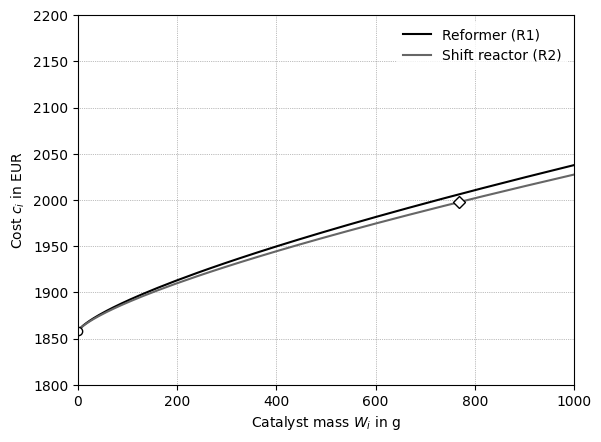

In [44]:
fig = plt.figure()
ax = fig.gca()

ax.plot(catalystMassRangeSI * 1e3, costValuesReformer, label="Reformer (R1)")
ax.plot(catalystMassRangeSI * 1e3, costValuesShift, label="Shift reactor (R2)")

ax.plot(
    1e3 * spaceTimeReformerSI * molarFlowRateReformerIn[Compound["C1H4(g)"].value],
    costReformer,
    "o",
    mec="k",
    mfc="white",
)
ax.plot(
    1e3 * spaceTimeShiftSI * molarFlowRateShiftIn[Compound["C1O1(g)"].value],
    costShift,
    "D",
    mec="k",
    mfc="white",
)

ax.set_xlabel(r"Catalyst mass $W_i$ in $\mathrm{g}$")
ax.set_ylabel(r"Cost $c_i$ in $\mathrm{EUR}$")
ax.legend()

ax.grid()

ax.set_xlim(0, 1000)
ax.set_ylim(1800, 2200)

## References
[back](#Table-of-contents)

1. Peters, M.S. et al. (2004) Plant design and economics for chemical engineers. 5. ed, international ed. 2004. Boston: McGraw-Hill (McGraw-Hill chemical engineering series).
2. Levenspiel, O. (1999) Chemical reaction engineering. 3rd ed. New York: Wiley.